## EDA

In [166]:
# =========================
# [1] IMPORT + SETTINGS + PATH
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"
SHEET_NAME = 0

TIMES = [1, 2, 3, 4]
MAX_PCT_FLOOR = 20.0

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [167]:
# =========================
# [2] LOAD FIBS: usa riga "Feature ID" come codici colonne metaboliti
# =========================
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

code_row = raw_f.iloc[0]                 # Feature ID (codici)
name_row = raw_f.iloc[1].astype(str)     # header (Code, Time, FI, ... + nomi metaboliti)
data_f   = raw_f.iloc[2:].copy()
data_f.columns = name_row

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]
meta_cols_fibs = [c for c in meta_cols_master if c in data_f.columns]

# rename: nome metabolita -> codice (stringa)
rename_fibs = {}
for j, col in enumerate(data_f.columns):
    if col in meta_cols_fibs:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    try:
        f = float(c)
        c_str = str(int(f)) if f.is_integer() else str(f)
    except:
        c_str = str(c).strip()
    rename_fibs[col] = c_str

df_fibs = data_f.rename(columns=rename_fibs).copy()

# typing
for c in ["Code","Time","FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")

df_fibs = df_fibs.dropna(subset=["Code","Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()

fibs_met_cols = [c for c in df_fibs.columns if c not in meta_cols_fibs]

print("FIBS shape:", df_fibs.shape)
print("FIBS metaboliti:", len(fibs_met_cols))

FIBS shape: (3342, 97)
FIBS metaboliti: 88


In [168]:
# =========================
# [3] LOAD MICROBIOTA: normalizza colonne + codici metaboliti come stringhe
# =========================
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]

# normalizza id/time
micro = micro.rename(columns={"TIME":"Time","time":"Time","ID Code":"Code","CODE":"Code","code":"Code"})

# se esistono colonne tipo Subject/ID inutili, le togliamo
micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore").copy()

micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code","Time"]).copy()

micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()

# normalizza nomi colonne metaboliti (es. 130604.0 -> "130604")
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

def norm_code(x):
    try:
        f = float(x)
        return str(int(f)) if f.is_integer() else str(f)
    except:
        return str(x).strip()

micro = micro.rename(columns={c: norm_code(c) for c in micro_met_cols})
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

# forza numerico nei metaboliti
micro[micro_met_cols] = micro[micro_met_cols].apply(pd.to_numeric, errors="coerce")

print("MICRO shape:", micro.shape)
print("MICRO metaboliti:", len(micro_met_cols))

MICRO shape: (3403, 110)
MICRO metaboliti: 107


In [169]:
# =========================
# [4] RIMUOVI DUPLICATI metaboliti: se codice esiste già in FIBS, lo tolgo da Microbiota
# =========================
dup_codes = sorted(list(set(micro_met_cols).intersection(set(fibs_met_cols))))
if dup_codes:
    print("Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota:", dup_codes)
    micro = micro.drop(columns=dup_codes).copy()

micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]
print("MICRO metaboliti dopo dedup:", len(micro_met_cols))

Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota: ['130604', '135585']
MICRO metaboliti dopo dedup: 105


In [170]:
# =========================
# [5] CONTROLLI PAZIENTI: tieni solo chi ha T1..T4 completi in ENTRAMBI (=> 609)
# =========================
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code","Time"]])
cc_micro = complete_codes(micro[["Code","Time"]])
common   = sorted(list(cc_fibs & cc_micro))

print("Pazienti completi (T1..T4) FIBS:", len(cc_fibs))
print("Pazienti completi (T1..T4) MICRO:", len(cc_micro))
print("Intersezione (useremo questi):", len(common))

only_fibs = sorted(list(cc_fibs - cc_micro))
if only_fibs:
    print("Pazienti completi solo in FIBS (esclusi):", only_fibs)

df_fibs_c = df_fibs[df_fibs["Code"].isin(common)].copy()
micro_c   = micro[micro["Code"].isin(common)].copy()

# merge finale su Code-Time
df = df_fibs_c.merge(micro_c, on=["Code","Time"], how="inner")

print("\nDF finale (FIBS + Microbiota):", df.shape)
print("Pazienti:", df["Code"].nunique(), "| righe attese:", df["Code"].nunique()*4, "| righe reali:", len(df))
print("Time presenti:", sorted(df["Time"].unique()))

Pazienti completi (T1..T4) FIBS: 610
Pazienti completi (T1..T4) MICRO: 609
Intersezione (useremo questi): 609
Pazienti completi solo in FIBS (esclusi): [34]

DF finale (FIBS + Microbiota): (2436, 203)
Pazienti: 609 | righe attese: 2436 | righe reali: 2436
Time presenti: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [171]:
# =========================
# [6] CHECK HARD: ogni paziente deve avere esattamente [1,2,3,4]
# =========================
chk = df.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
bad = chk[chk.apply(lambda t: t != TIMES)]

print("Pazienti con timepoint non perfetti:", bad.shape[0])
if bad.shape[0] > 0:
    display(bad.head(20))

Pazienti con timepoint non perfetti: 0


In [172]:
# =========================
# [7] DEFINISCI META VS METABOLITI (evita errori tipo 'Subject')
# =========================
meta_cols = [c for c in meta_cols_master if c in df.columns]
keep_meta = ["Code","Time"]
if "FI" in df.columns: 
    keep_meta.append("FI")

# aggiungi gli altri meta se presenti
for c in meta_cols:
    if c not in keep_meta:
        keep_meta.append(c)

met_cols_all = [c for c in df.columns if c not in keep_meta]

# forza numerico solo metaboliti
df[met_cols_all] = df[met_cols_all].apply(pd.to_numeric, errors="coerce")

print("Meta columns:", keep_meta)
print("Metaboliti totali:", len(met_cols_all))
print("Esempio metaboliti:", met_cols_all[:10])

Meta columns: ['Code', 'Time', 'FI', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject']
Metaboliti totali: 193
Esempio metaboliti: ['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087']


In [173]:
# =========================
# [8] FILTER 1: TOGLI metaboliti con anche 1 solo NaN (stampa lista)
# =========================
nan_any = df[met_cols_all].isna().any(axis=0)

mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()

print("Metaboliti con >=1 NaN (da togliere):", len(mets_with_nan))
if len(mets_with_nan) > 0:
    print(mets_with_nan[:80], "..." if len(mets_with_nan) > 80 else "")

df_nn = df[keep_meta + mets_no_nan].copy()
met_cols_nn = mets_no_nan

print("Metaboliti rimasti senza NaN:", len(met_cols_nn))
print("df_nn shape:", df_nn.shape)

Metaboliti con >=1 NaN (da togliere): 0
Metaboliti rimasti senza NaN: 193
df_nn shape: (2436, 203)


In [174]:
# =========================
# [9] FILTER 2: floor = MIN del metabolita, togli %floor > 50
# =========================
# floor per colonna = minimo valore (ignora NaN, ma qui non ce ne sono)
floors = df_nn[met_cols_nn].min(axis=0)

# % valori uguali al floor
is_floor = df_nn[met_cols_nn].eq(floors, axis=1)
pct_floor = is_floor.mean(axis=0) * 100

mets_high_floor = pct_floor[pct_floor > MAX_PCT_FLOOR].index.tolist()
mets_ok_floor   = pct_floor[pct_floor <= MAX_PCT_FLOOR].index.tolist()

print("Metaboliti con %floor > 50 (da togliere):", len(mets_high_floor))
if len(mets_high_floor) > 0:
    print(mets_high_floor[:80], "..." if len(mets_high_floor) > 80 else "")

df_eda = df_nn[keep_meta + mets_ok_floor].copy()
met_cols_eda = mets_ok_floor

print("\nDF EDA finale:", df_eda.shape)
print("Metaboliti finali:", len(met_cols_eda))

Metaboliti con %floor > 50 (da togliere): 177
['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087', '119236', '168490', '138907', '121811', '120572', '117118', '117123', '127908', '115216', '77320', '140845', '108360', '126673', '95952', '132791', '131236', '110861', '168439', '119396', '107734', '114147', '126338', '130604', '148452', '115483', '133194', '97085', '132942', '139970', '112827', '148969', '135585', '139688', '102818', '95488', '126961', '125270', '119670', '138928', '145525', '143390', '102381', '146389', '139429', '69769', '70501', '88906', '99957', '100525', '105612', '107230', '107747', '115097', '125698', '128641', '132923', '141889', '142686', '154201', '154261', '154918', '154982', '155702', '156439', '173108', '182877', '192291', '199458', '207856', '13944'] ...

DF EDA finale: (2436, 26)
Metaboliti finali: 16


In [175]:
# =========================
# [9B] RINOMINA SOLO I METABOLITI FIBS: feature_id -> nome
# da fare DOPO i controlli EDA
# =========================

# ricostruisco la mappa feature_id -> nome da FIBS
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

feature_row = raw_f.iloc[0]              # feature IDs
name_row    = raw_f.iloc[1].astype(str)  # nomi metaboliti / header

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]

fibs_code_to_name = {}

for j in range(len(name_row)):
    nm = str(name_row.iloc[j]).strip()
    if nm in meta_cols_master:
        continue

    fid = feature_row.iloc[j]
    if pd.isna(fid):
        continue

    try:
        f = float(fid)
        fid_str = str(int(f)) if f.is_integer() else str(f)
    except:
        fid_str = str(fid).strip()

    fibs_code_to_name[fid_str] = nm

# rinomina solo le colonne presenti in df_eda e appartenenti a FIBS
rename_after_eda = {c: fibs_code_to_name[c] for c in met_cols_eda if c in fibs_code_to_name}

# controllo sicurezza: evita collisioni di nomi
name_counts = pd.Series(rename_after_eda.values()).value_counts()
dup_names = name_counts[name_counts > 1].index.tolist()

if len(dup_names) > 0:
    print("Attenzione: ci sono nomi duplicati in FIBS, li lascio come codice per sicurezza.")
    for old_code, new_name in list(rename_after_eda.items()):
        if new_name in dup_names:
            rename_after_eda[old_code] = old_code

df_eda = df_eda.rename(columns=rename_after_eda).copy()

# aggiorna lista metaboliti finali
met_cols_eda = [rename_after_eda.get(c, c) for c in met_cols_eda]

print("Metaboliti FIBS rinominati:", len(rename_after_eda))
print("Esempio:", list(rename_after_eda.items())[:10])
print("Numero metaboliti finali:", len(met_cols_eda))

Metaboliti FIBS rinominati: 9
Esempio: [('74059', 'Benzoic acid'), ('99108', '3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;'), ('131116', 'Enterodiol'), ('98644', 'Uric acid'), ('96492', '2-Hydroxycinnamic acid'), ('105611', 'Hippuric acid'), ('106160', 'myo-Inositol'), ('115109', '5-acetylamino-6-amino-3-methyluracil ((AAMU)'), ('159176', 'Isorhamnetin')]
Numero metaboliti finali: 16


Pazienti: 609
Time: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Righe: 2436


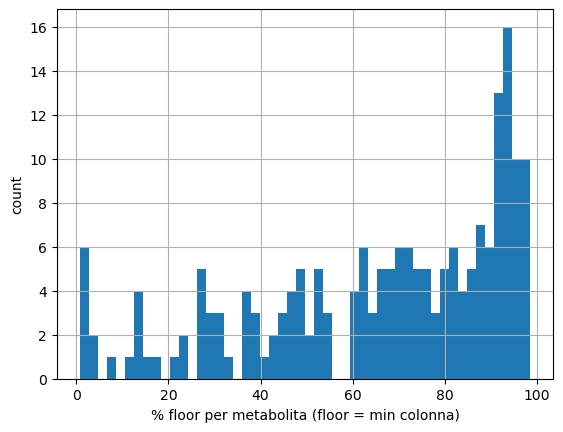

,pct_floor
143390,98.604269
154201,98.193760
88906,98.152709
173108,97.906404
105612,97.824302
133194,97.783251
132791,97.413793
134424,97.126437
122834,97.044335
132322,96.798030


In [176]:
# =========================
# [10] MINI-REPORT EDA: distribuzione %floor + sanity check
# =========================
print("Pazienti:", df_eda["Code"].nunique())
print("Time:", sorted(df_eda["Time"].unique()))
print("Righe:", len(df_eda))

plt.figure()
pct_floor.hist(bins=50)
plt.xlabel("% floor per metabolita (floor = min colonna)")
plt.ylabel("count")
plt.show()

# esempio: 10 metaboliti con più floor
top_floor = pct_floor.sort_values(ascending=False).head(10)
display(top_floor.to_frame("pct_floor"))

## Correlazione 

In [177]:
# =========================
# [C1] PREPARA MATRICE METABOLITI PER CORRELAZIONE
# =========================
import numpy as np
import pandas as pd

# solo metaboliti finali della parte EDA
X = df_eda[met_cols_eda].apply(pd.to_numeric, errors="coerce").copy()

print("Shape X:", X.shape)
print("Numero metaboliti:", X.shape[1])
print("NaN totali:", int(np.isnan(X.to_numpy()).sum()))

Shape X: (2436, 16)
Numero metaboliti: 16
NaN totali: 0


In [178]:
# =========================
# [C2] LOG10 DEI METABOLITI (valori <= 0 -> NaN)
# =========================
X_log = np.log10(X.where(X > 0, np.nan))

print("Shape X_log:", X_log.shape)
print("NaN totali dopo log10:", int(np.isnan(X_log.to_numpy()).sum()))
print("Metaboliti con almeno 1 valore valido dopo log10:", int((X_log.notna().sum(axis=0) > 0).sum()))

Shape X_log: (2436, 16)
NaN totali dopo log10: 0
Metaboliti con almeno 1 valore valido dopo log10: 16


In [179]:
# =========================
# [C3] MATRICE DI CORRELAZIONE
# =========================
import matplotlib.pyplot as plt

METHOD = "spearman"   # consigliato qui

corr = X_log.corr(method=METHOD)



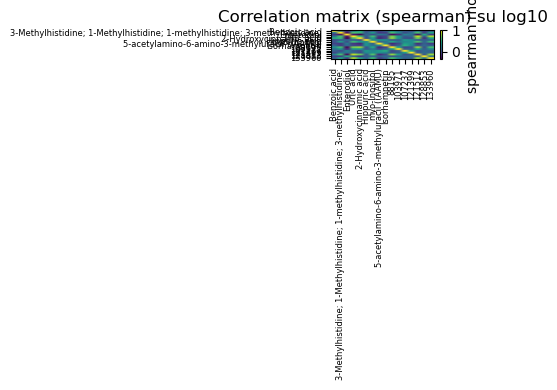

In [180]:
# =========================
# [C4] HEATMAP DELLA MATRICE DI CORRELAZIONE
# =========================
plt.figure(figsize=(5, 4))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label=f"{METHOD} rho")
plt.title(f"Correlation matrix ({METHOD}) su log10")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.tight_layout()
plt.show()

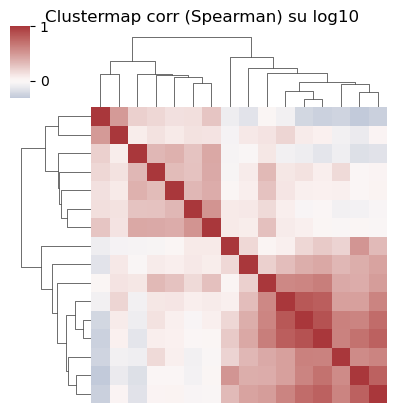

In [181]:
# =========================
# [C5] CLUSTERMAP DELLA CORRELAZIONE
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    corr,
    figsize=(4, 4),
    cmap="vlag",
    center=0,
    linewidths=0,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle("Clustermap corr (Spearman) su log10", y=1.02)
plt.show()

In [182]:
# =========================
# [C6] ESTRAI LE COPPIE DI METABOLITI PIÙ CORRELATE
# =========================
TH = 0.8   # soglia su |rho|

c = corr.copy()

# upper triangle senza diagonale
mask = np.triu(np.ones(c.shape, dtype=bool), k=1)

i, j = np.where(mask)
rho = c.to_numpy()[i, j]

vals = pd.DataFrame({
    "met1": c.index.to_numpy()[i],
    "met2": c.columns.to_numpy()[j],
    "rho": rho
})

vals = vals.dropna(subset=["rho"]).copy()
vals["abs_rho"] = vals["rho"].abs()
vals = vals.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print(f"Coppie totali (uniche): {vals.shape[0]}")
print(f"Coppie con |rho| > {TH}: {int((vals['abs_rho'] > TH).sum())}")

display(vals.head(20))

Coppie totali (uniche): 120
Coppie con |rho| > 0.8: 2


,met1,met2,rho,abs_rho
0,Uric acid,121512,0.864476,0.864476
1,Uric acid,133960,0.825727,0.825727
2,121512,133960,0.796143,0.796143
3,2-Hydroxycinnamic acid,88195,0.782559,0.782559
4,88195,121512,0.781937,0.781937
5,Uric acid,88195,0.724956,0.724956
6,2-Hydroxycinnamic acid,121512,0.697858,0.697858
7,myo-Inositol,121512,0.638866,0.638866
8,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,Uric acid,0.618866,0.618866
9,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,121512,0.614120,0.614120


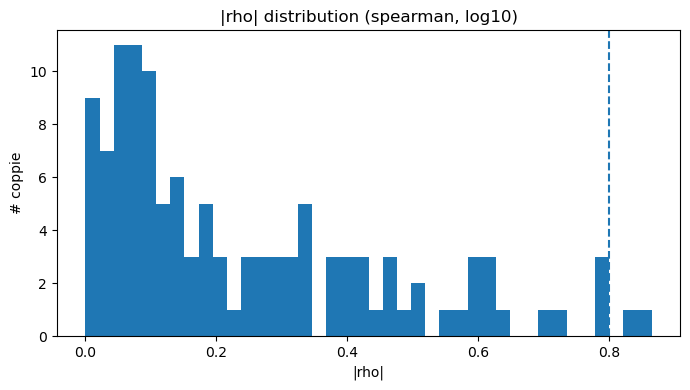

In [183]:
# =========================
# [C7] ISTOGRAMMA DELLE |CORRELAZIONI|
# =========================
plt.figure(figsize=(7, 4))
plt.hist(vals["abs_rho"].dropna().values, bins=40)
plt.axvline(TH, linestyle="--")
plt.title(f"|rho| distribution ({METHOD}, log10)")
plt.xlabel("|rho|")
plt.ylabel("# coppie")
plt.tight_layout()
plt.show()

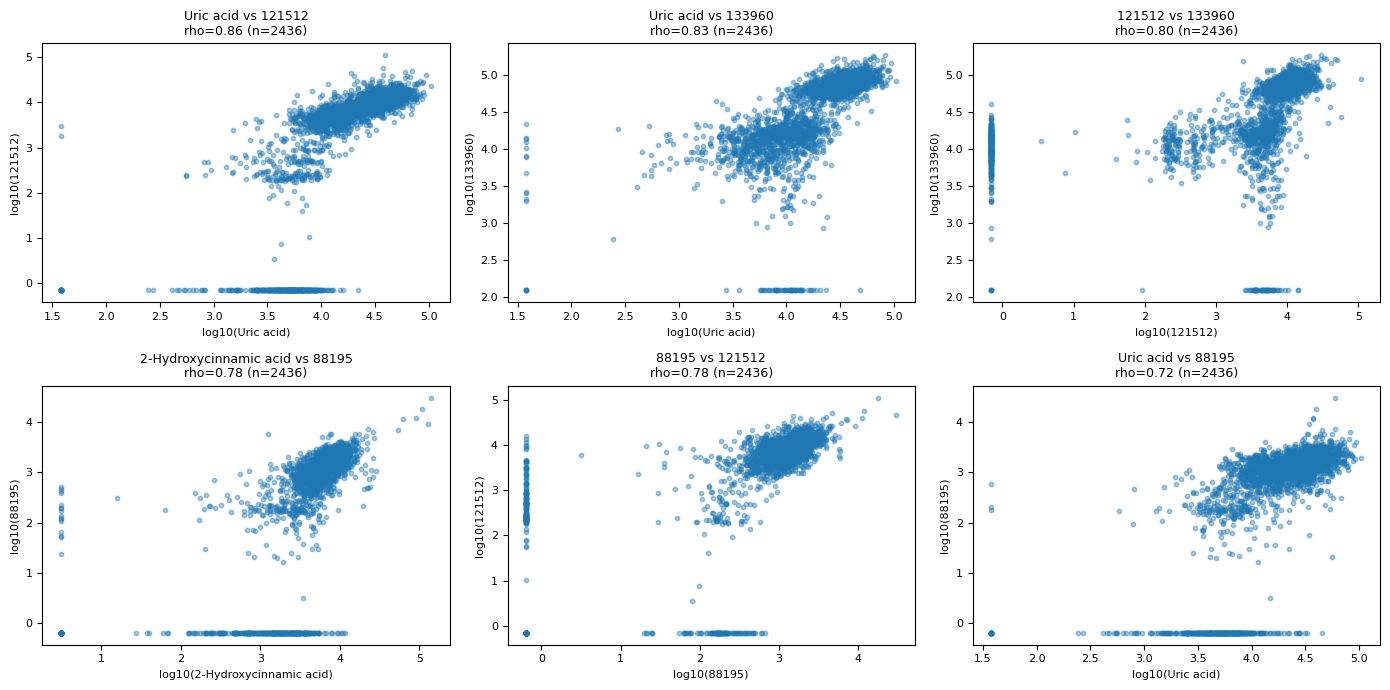

In [184]:
# =========================
# [C9] SCATTER DELLE COPPIE PIÙ CORRELATE
# =========================
N_SCATTER = 6

pairs_to_plot = vals.sort_values("abs_rho", ascending=False).head(N_SCATTER).copy()

fig, axes = plt.subplots(2, int(np.ceil(N_SCATTER / 2)), figsize=(14, 7))
axes = axes.ravel()

for k, row in enumerate(pairs_to_plot.itertuples(index=False)):
    m1, m2, rho, abs_rho = row.met1, row.met2, row.rho, row.abs_rho
    ax = axes[k]

    x = X_log[m1]
    y = X_log[m2]
    ok = x.notna() & y.notna()

    ax.scatter(x[ok].values, y[ok].values, s=10, alpha=0.4)
    ax.set_title(f"{m1} vs {m2}\nrho={rho:.2f} (n={int(ok.sum())})", fontsize=9)
    ax.set_xlabel(f"log10({m1})", fontsize=8)
    ax.set_ylabel(f"log10({m2})", fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(k + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Spline mixed model

In [224]:
# =========================
# [FIM1] IMPORT + SETTINGS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import bs

TIMES = [1,2,3,4]
TIME_TO_YEARS = {1: 0.0, 2: 2.0, 3: 4.0, 4: 8.0}

FRAIL_THR = 0.25
Q_FDR = 0.05

SPLINE_DF = 3
EPS = 1e-9  # per log10(x + EPS) anche se x=0

def fdr_bh(p):
    p = pd.to_numeric(p, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    m = p.notna() & np.isfinite(p) & (p >= 0) & (p <= 1)
    if m.sum() > 0:
        out.loc[m] = multipletests(p.loc[m].values, method="fdr_bh")[1]
    return out

In [225]:
# =========================
# [FIM2] BASE LONG: FI + tempo reale (anni) + gruppo ever/never
# Usa df_eda e met_cols_eda (già puliti, con floor inclusi)
# =========================
# NB: se i tuoi metaboliti finali non sono met_cols_eda, cambia qui.
mets = list(met_cols_eda)

base = df_eda[["Code","Time","FI"] + mets].copy()

base["Code"] = pd.to_numeric(base["Code"], errors="coerce").astype(int)
base["Time"] = pd.to_numeric(base["Time"], errors="coerce").astype(int)
base["FI"]   = pd.to_numeric(base["FI"], errors="coerce")

base = base.dropna(subset=["Code","Time","FI"]).copy()
base = base[base["Time"].isin(TIMES)].sort_values(["Code","Time"]).copy()

# tieni solo pazienti completi T1..T4
n_tp = base.groupby("Code")["Time"].nunique()
keep_codes = n_tp[n_tp == len(TIMES)].index
base = base[base["Code"].isin(keep_codes)].copy()

# tempo reale
base["t_years"] = base["Time"].map(TIME_TO_YEARS).astype(float)
base["t"] = base["t_years"] / base["t_years"].max()

# gruppo ever/never frail (da FI)
ever = base.groupby("Code")["FI"].max() >= FRAIL_THR
base["frail_group"] = base["Code"].map(ever.map({True: "Ever-frail", False: "Never-frail"}))
base["frail_group"] = pd.Categorical(base["frail_group"], categories=["Never-frail","Ever-frail"])

print("Righe:", len(base), "| Pazienti:", base["Code"].nunique())
print(base["frail_group"].value_counts())
print(base[["Time","t_years","t"]].drop_duplicates().sort_values("Time"))

Righe: 2436 | Pazienti: 609
frail_group
Never-frail    1828
Ever-frail      608
Name: count, dtype: int64
   Time  t_years     t
0     1      0.0  0.00
1     2      2.0  0.25
2     3      4.0  0.50
3     4      8.0  1.00


In [226]:
# =========================
# [FIM3] TRASFORMAZIONE + NORMALIZZAZIONE METABOLITI
# log10(x+EPS) + z-score per colonna (usa anche i floor)
# =========================
# forza numerico
base[mets] = base[mets].apply(pd.to_numeric, errors="coerce")

# log10 con floor incluso
Xlog = np.log10(base[mets] + EPS)

# z-score (mean 0, std 1) per metabolita
mu = Xlog.mean(axis=0)
sd = Xlog.std(axis=0, ddof=0).replace(0, np.nan)

Xz = (Xlog - mu) / sd
Xz = Xz.fillna(0.0)  # se sd=0 (raro), mette a 0

# attacca al dataset con nomi safe (evita caratteri strani nelle formule)
met_safe = {m: f"M{i:02d}" for i, m in enumerate(mets)}
base_z = base[["Code","FI","Time","t","t_years","frail_group"]].copy()

for m in mets:
    base_z[met_safe[m]] = Xz[m].astype(float)

print("Metaboliti (safe names):", len(met_safe))
list(met_safe.items())[:5]

Metaboliti (safe names): 16


[('Benzoic acid', 'M00'),
 ('3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;',
  'M01'),
 ('Enterodiol', 'M02'),
 ('Uric acid', 'M03'),
 ('2-Hydroxycinnamic acid', 'M04')]

In [227]:
# =========================
# [FIM4] MODELLO BASE (solo drift + random intercept)
# FI ~ bs(t) + (1|Code)
# =========================
formula0 = f"FI ~ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md0 = smf.mixedlm(formula0, data=base_z, groups=base_z["Code"])
fit0 = md0.fit(reml=False, method="lbfgs", disp=False)

print(fit0.summary().tables[1])

                                                   Coef. Std.Err.       z  \
Intercept                                          0.105    0.003  34.053   
bs(t, df=3, degree=3, include_intercept=False)[0]  0.029    0.008   3.568   
bs(t, df=3, degree=3, include_intercept=False)[1]  0.029    0.010   2.921   
bs(t, df=3, degree=3, include_intercept=False)[2]  0.086    0.003  33.221   
Group Var                                          0.004    0.006           

                                                   P>|z| [0.025 0.975]  
Intercept                                          0.000  0.099  0.111  
bs(t, df=3, degree=3, include_intercept=False)[0]  0.000  0.013  0.045  
bs(t, df=3, degree=3, include_intercept=False)[1]  0.003  0.009  0.048  
bs(t, df=3, degree=3, include_intercept=False)[2]  0.000  0.081  0.091  
Group Var                                                               


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



In [228]:
# =========================
# [FIM5] MODELLO 1: FI ~ metaboliti + bs(t) + (1|Code)
# (associazioni globali, senza gruppi)
# =========================
met_terms = " + ".join(met_safe.values())
formula1 = f"FI ~ {met_terms} + bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md1 = smf.mixedlm(formula1, data=base_z, groups=base_z["Code"])
fit1 = md1.fit(reml=False, method="lbfgs", disp=False)

# estrai p-values solo per metaboliti
p_met = pd.Series({v: float(fit1.pvalues.get(v, np.nan)) for v in met_safe.values()})
q_met = fdr_bh(p_met)

tab1 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "metabolite_term": list(met_safe.values()),
    "beta": [float(fit1.params.get(v, np.nan)) for v in met_safe.values()],
    "p": p_met.values,
    "q": q_met.values
}).sort_values("q")

print("Significativi (q<0.05):", int((tab1["q"] < Q_FDR).sum()))
display(tab1.head(30))

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



Significativi (q<0.05): 7


,metabolite_original,metabolite_term,beta,p,q
5,Hippuric acid,M05,-0.008347,5.969541e-07,0.000010
0,Benzoic acid,M00,-0.003992,4.022688e-04,0.003218
7,5-acetylamino-6-amino-3-methyluracil ((AAMU),M07,-0.004108,4.923893e-03,0.019720
8,Isorhamnetin,M08,0.005166,4.929958e-03,0.019720
9,88195,M09,-0.005033,6.433260e-03,0.020586
3,Uric acid,M03,0.005448,1.045794e-02,0.026868
12,121399,M12,0.004832,1.175459e-02,0.026868
11,107237,M11,0.002180,1.691205e-01,0.338241
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,M01,-0.001370,3.822258e-01,0.611561
14,128853,M14,-0.001054,3.524688e-01,0.611561


In [229]:
# =========================
# [FIM6] MODELLO 2: FI ~ metaboliti + group + (metaboliti×group) + bs(t) + (1|Code)
# per capire quali metaboliti "pesano" diversamente tra Ever vs Never
# =========================
# main effects metaboliti
met_main = " + ".join(met_safe.values())

# interazioni metabolita:group (Ever-frail vs Never-frail)
met_int = " + ".join([f"{v}:C(frail_group)" for v in met_safe.values()])

formula2 = (
    f"FI ~ {met_main} + C(frail_group) + {met_int} "
    f"+ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"
)

md2 = smf.mixedlm(formula2, data=base_z, groups=base_z["Code"])
fit2 = md2.fit(reml=False, method="lbfgs", disp=False)

# p-values per:
# - main metaboliti (effetto in Never-frail, gruppo di riferimento)
# - interazioni (delta effetto in Ever-frail)
p_main = pd.Series({v: float(fit2.pvalues.get(v, np.nan)) for v in met_safe.values()})
p_int  = pd.Series({v: float(fit2.pvalues.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()})

q_main = fdr_bh(p_main)
q_int  = fdr_bh(p_int)

tab2 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "term": list(met_safe.values()),
    "beta_main_Never": [float(fit2.params.get(v, np.nan)) for v in met_safe.values()],
    "q_main": q_main.values,
    "beta_interaction_Ever_minus_Never": [float(fit2.params.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()],
    "q_interaction": q_int.values
})

tab2["beta_Ever"] = tab2["beta_main_Never"] + tab2["beta_interaction_Ever_minus_Never"]

tab2 = tab2.sort_values(["q_interaction","q_main"])

print("Interazioni significative (q<0.05):", int((tab2["q_interaction"] < Q_FDR).sum()))
print("Main effects significativi (q<0.05):", int((tab2["q_main"] < Q_FDR).sum()))
display(tab2.head(30))

Interazioni significative (q<0.05): 8
Main effects significativi (q<0.05): 3


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



,metabolite_original,term,beta_main_Never,q_main,beta_interaction_Ever_minus_Never,q_interaction,beta_Ever
6,myo-Inositol,M06,-0.006650,0.009511,0.024181,1.691527e-10,0.017531
0,Benzoic acid,M00,-0.000014,0.990574,-0.012449,7.525741e-07,-0.012464
12,121399,M12,-0.000203,0.980641,0.020038,1.714632e-06,0.019834
11,107237,M11,0.004773,0.014619,-0.016104,2.647280e-05,-0.011331
7,5-acetylamino-6-amino-3-methyluracil ((AAMU),M07,-0.001188,0.687797,-0.011368,4.886546e-04,-0.012556
9,88195,M09,0.000376,0.973890,-0.013583,4.886546e-04,-0.013207
5,Hippuric acid,M05,-0.003284,0.200436,-0.013845,5.971052e-04,-0.017129
10,103971,M10,0.002350,0.267605,-0.009423,1.918065e-03,-0.007073
13,121512,M13,-0.003219,0.327256,0.008127,6.539481e-02,0.004908
14,128853,M14,-0.002295,0.200436,0.003611,1.844632e-01,0.001315


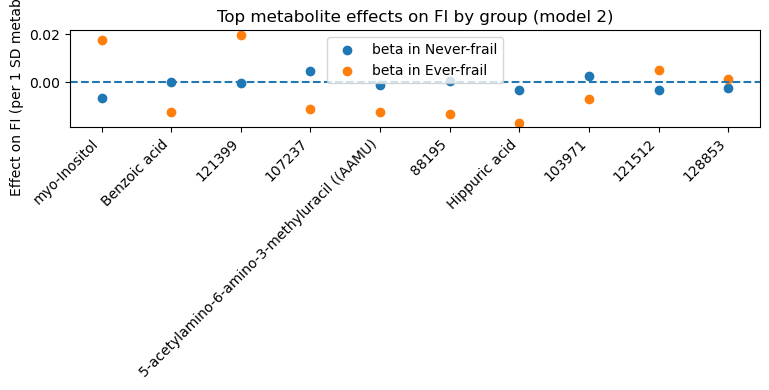

In [230]:
# =========================
# [FIM7] PLOT: TOP metaboliti (per interazione) — effetto stimato in Never vs Ever
# =========================
TOPK = 10
top_int = tab2.sort_values("q_interaction").head(TOPK)

plt.figure(figsize=(8,4))
x = np.arange(len(top_int))
plt.scatter(x, top_int["beta_main_Never"].values, label="beta in Never-frail")
plt.scatter(x, top_int["beta_Ever"].values, label="beta in Ever-frail")
plt.axhline(0, linestyle="--")
plt.xticks(x, top_int["metabolite_original"].astype(str).values, rotation=45, ha="right")
plt.ylabel("Effect on FI (per 1 SD metabolite)")
plt.title("Top metabolite effects on FI by group (model 2)")
plt.legend()
plt.tight_layout()
plt.show()

In [231]:
# =========================
# [FIM8] DIAGNOSTICA SEMPLICE: confronto modello base vs con metaboliti
# (AIC più basso = meglio, in generale)
# =========================
print("AIC model0 (time only):", fit0.aic)
print("AIC model1 (+ metabolites):", fit1.aic)
print("AIC model2 (+ group + interactions):", fit2.aic)

AIC model0 (time only): -6871.793419288297
AIC model1 (+ metabolites): -6919.311053335045
AIC model2 (+ group + interactions): -7506.963074890151


## Reg

In [300]:
# =========================
# [FI-MET1] IMPORT + SETTINGS
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

TIMES = [1,2,3,4]
TIME_TO_YEARS = {1: 0.0, 2: 2.0, 3: 4.0, 4: 8.0}

EPS = 1e-9
N_SPLINES = 5          # flessibilità drift (con 4 timepoint basta piccolo)
ALPHA_RIDGE = 1.0      # regolarizzazione
N_SPLITS = 5
N_REPEATS_PI = 10      # permutation importance repeats (più alto = più stabile)
RANDOM_STATE = 0

In [301]:
# =========================
# [FI-MET2] PREPARA DATASET LONG (609 soggetti completi)
# =========================
mets = list(met_cols_eda)

df = df_eda[["Code","Time","FI"] + mets].copy()
df["Code"] = pd.to_numeric(df["Code"], errors="coerce").astype(int)
df["Time"] = pd.to_numeric(df["Time"], errors="coerce").astype(int)
df["FI"]   = pd.to_numeric(df["FI"], errors="coerce")

df = df.dropna(subset=["Code","Time","FI"]).copy()
df = df[df["Time"].isin(TIMES)].copy()
df["t_years"] = df["Time"].map(TIME_TO_YEARS).astype(float)

# solo soggetti completi T1..T4
n_tp = df.groupby("Code")["Time"].nunique()
subjects = np.array(sorted(n_tp[n_tp == len(TIMES)].index.astype(int)))
df = df[df["Code"].isin(subjects)].copy()

# forza numerico metaboliti
df[mets] = df[mets].apply(pd.to_numeric, errors="coerce")

# check NaN
if df[mets].isna().any().any():
    raise ValueError("Ci sono NaN nei metaboliti: ricontrolla la fase EDA.")

print("Righe:", len(df), "| Pazienti:", df["Code"].nunique(), "| Metaboliti:", len(mets))
display(df.head())

Righe: 2436 | Pazienti: 609 | Metaboliti: 16


,Code,Time,FI,Benzoic acid,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Enterodiol,Uric acid,2-Hydroxycinnamic acid,Hippuric acid,myo-Inositol,5-acetylamino-6-amino-3-methyluracil ((AAMU),Isorhamnetin,88195,103971,107237,121399,121512,128853,133960,t_years
0,9,1,0.060606,3639.20,6492.7,1602.3,18152.1,6964.7,1.2,207.2,2.26,5.84,1914.10,8718.0,4.18,6.0,13179.9,0.02,97856.4,0.0
1,9,2,0.060606,3262.80,6380.9,144.8,5879.2,9701.6,12410.5,85151.5,80.00,18494.20,1257.20,748.1,678.00,5040.8,5254.0,436.90,121.3,2.0
2,9,3,0.060606,996.90,6249.1,3678.7,2505.9,7834.5,16438.2,68943.1,1397.00,14540.00,0.64,1.2,1138.80,7044.9,0.7,129.20,40163.9,4.0
3,9,4,0.096774,0.22,8456.9,2056.0,2757.7,934.8,22641.0,84477.2,7584.40,30267.60,0.64,1.2,2088.10,10414.4,0.7,875.80,10240.8,8.0
4,11,1,0.166667,3542.00,13480.7,770.9,14981.3,8229.1,105021.7,199112.7,7361.00,105893.60,2093.50,50195.6,4623.90,41849.4,8037.6,1093.90,26164.1,0.0


In [302]:
# =========================
# [FI-MET3] DEFINISCI FEATURE + PIPELINE (time spline + metaboliti log+zscore)
# =========================
X = df[["t_years"] + mets].copy()
y = df["FI"].to_numpy(dtype=float)
groups = df["Code"].to_numpy()

# log10(x+eps) sui metaboliti
def log_eps(Xm):
    return np.log10(Xm + EPS)

met_pipe = Pipeline(steps=[
    ("log", FunctionTransformer(log_eps, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

time_pipe = Pipeline(steps=[
    ("spline", SplineTransformer(n_knots=N_SPLINES, degree=3, include_bias=False)),
    ("scaler", StandardScaler(with_mean=False))  # sparse-friendly
])

preprocess_full = ColumnTransformer(
    transformers=[
        ("time", time_pipe, ["t_years"]),
        ("met", met_pipe, mets),
    ],
    remainder="drop"
)

preprocess_time_only = ColumnTransformer(
    transformers=[
        ("time", time_pipe, ["t_years"]),
    ],
    remainder="drop"
)

model = Ridge(alpha=ALPHA_RIDGE, random_state=RANDOM_STATE)

pipe_full = Pipeline(steps=[("prep", preprocess_full), ("model", model)])
pipe_time = Pipeline(steps=[("prep", preprocess_time_only), ("model", model)])

In [303]:
# =========================
# [FI-MET4] CV by subject: RMSE baseline (time-only) vs full (time+metaboliti)
# =========================
cv = GroupKFold(n_splits=N_SPLITS)

rmse_time = []
rmse_full = []

for tr, te in cv.split(X, y, groups=groups):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y[tr], y[te]

    pipe_time.fit(Xtr, ytr)
    pred_time = pipe_time.predict(Xte)
    rmse_time.append(np.sqrt(mean_squared_error(yte, pred_time)))

    pipe_full.fit(Xtr, ytr)
    pred_full = pipe_full.predict(Xte)
    rmse_full.append(np.sqrt(mean_squared_error(yte, pred_full)))

print("RMSE time-only  (mean±std):", float(np.mean(rmse_time)), "±", float(np.std(rmse_time)))
print("RMSE time+met   (mean±std):", float(np.mean(rmse_full)), "±", float(np.std(rmse_full)))
print("ΔRMSE (full - time):", float(np.mean(rmse_full) - np.mean(rmse_time)))

RMSE time-only  (mean±std): 0.07623083504863275 ± 0.003261062562133002
RMSE time+met   (mean±std): 0.07591022626591752 ± 0.003803597372111723
ΔRMSE (full - time): -0.00032060878271522597


In [304]:
# =========================
# [FI-MET5] PERMUTATION IMPORTANCE (CV): ranking metaboliti per utilità su RMSE
# =========================
# Importanza = aumento dell'errore quando permuto una feature.
# Qui usiamo scoring = negative RMSE => più negativo = peggio => importance positiva = peggiora rmse.

importances = {m: [] for m in mets}

for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), start=1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y[tr], y[te]

    pipe_full.fit(Xtr, ytr)

    # Permutation importance sul set test del fold
    pi = permutation_importance(
        pipe_full, Xte, yte,
        scoring="neg_root_mean_squared_error",
        n_repeats=N_REPEATS_PI,
        random_state=RANDOM_STATE
    )

    # pi.importances_mean è per le colonne di X (t_years + mets)
    cols = ["t_years"] + mets
    imp = pd.Series(pi.importances_mean, index=cols)

    # prendo solo metaboliti
    for m in mets:
        importances[m].append(float(imp[m]))

# aggrega
rank = pd.DataFrame({
    "metabolite": mets,
    "mean_importance": [np.mean(importances[m]) for m in mets],
    "std_importance":  [np.std(importances[m]) for m in mets]
}).sort_values("mean_importance", ascending=False).reset_index(drop=True)

display(rank.head(20))

,metabolite,mean_importance,std_importance
0,88195,0.002216,0.000806
1,Hippuric acid,0.001831,0.000539
2,121399,0.000711,0.000232
3,Uric acid,0.000594,0.000482
4,myo-Inositol,0.000585,0.000265
5,Benzoic acid,0.000239,0.000134
6,5-acetylamino-6-amino-3-methyluracil ((AAMU),0.000116,0.000163
7,Isorhamnetin,0.000062,0.000165
8,2-Hydroxycinnamic acid,0.000055,0.000099
9,128853,0.000047,0.000035


/var/folders/71/8hrhfywn56lfsgx6pcgmxww00000gn/T/ipykernel_52565/3788854818.py:19: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



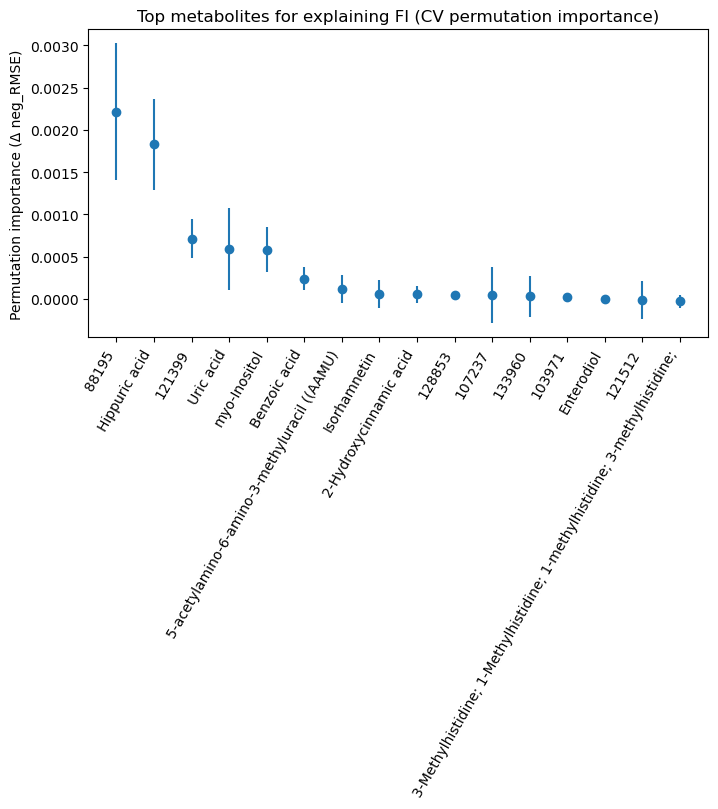

In [306]:
# =========================
# [FI-MET6] PLOT ranking (Top 15) — quanto peggiora RMSE se rompo il metabolita
# =========================
import matplotlib.pyplot as plt

TOPK = 16
top = rank.head(TOPK).copy()

plt.figure(figsize=(8,4))
plt.errorbar(
    x=np.arange(TOPK),
    y=top["mean_importance"].values,
    yerr=top["std_importance"].values,
    fmt="o"
)
plt.xticks(np.arange(TOPK), top["metabolite"].astype(str).values, rotation=60, ha="right")
plt.ylabel("Permutation importance (Δ neg_RMSE)")
plt.title("Top metabolites for explaining FI (CV permutation importance)")
plt.tight_layout()
plt.show()

In [307]:
# =========================
# [FI-MET7] COSTRUISCI metaboliti BETWEEN/WITHIN (sui log10)
# =========================
df_bw = df[["Code", "t_years", "FI"] + mets].copy()

# log10 con floor incluso
for m in mets:
    df_bw[m] = np.log10(df_bw[m].astype(float) + EPS)

# between = media soggetto
met_between = df_bw.groupby("Code")[mets].transform("mean")
for m in mets:
    df_bw[f"{m}__between"] = met_between[m]
    df_bw[f"{m}__within"]  = df_bw[m] - df_bw[f"{m}__between"]

# standardizza (global) within/between per confrontare beta
bw_cols = [f"{m}__between" for m in mets] + [f"{m}__within" for m in mets]
df_bw[bw_cols] = (df_bw[bw_cols] - df_bw[bw_cols].mean()) / (df_bw[bw_cols].std(ddof=0) + 1e-12)

display(df_bw.head())

,Code,t_years,FI,Benzoic acid,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Enterodiol,Uric acid,2-Hydroxycinnamic acid,Hippuric acid,myo-Inositol,5-acetylamino-6-amino-3-methyluracil ((AAMU),Isorhamnetin,88195,103971,107237,121399,121512,128853,133960,Benzoic acid__between,Benzoic acid__within,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;__between,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;__within,Enterodiol__between,Enterodiol__within,Uric acid__between,Uric acid__within,2-Hydroxycinnamic acid__between,2-Hydroxycinnamic acid__within,Hippuric acid__between,Hippuric acid__within,myo-Inositol__between,myo-Inositol__within,5-acetylamino-6-amino-3-methyluracil ((AAMU)__between,5-acetylamino-6-amino-3-methyluracil ((AAMU)__within,Isorhamnetin__between,Isorhamnetin__within,88195__between,88195__within,103971__between,103971__within,107237__between,107237__within,121399__between,121399__within,121512__between,121512__within,128853__between,128853__within,133960__between,133960__within
0,9,0.0,0.060606,3.561006,3.812425,3.204744,4.258927,3.842902,0.079181,2.316390,0.354108,0.766413,3.281965,3.940417,0.621176,0.778151,4.119912,-1.698970,4.990589,-0.692826,0.956505,0.486546,-0.020230,0.824656,0.123485,-1.948644,1.426135,0.324841,0.285048,-2.169303,-5.221513,-3.918271,-5.237028,-0.799204,-2.996683,-3.360976,-5.171439,-1.842438,1.631893,-1.649110,2.021554,-2.043527,-3.797785,-2.132123,-5.071870,-2.014664,1.775553,-0.516933,-2.140359,-1.897649,2.132509
1,9,2.0,0.060606,3.513590,3.804882,2.160769,3.769318,3.986843,4.093789,4.930192,1.903090,4.267036,3.099404,2.873960,2.831230,3.702499,3.720490,2.640382,2.083861,-0.692826,0.918932,0.486546,-0.026965,0.824656,-0.773712,-1.948644,0.137826,0.324841,0.527423,-2.169303,1.525839,-3.918271,1.831451,-0.799204,-0.636207,-3.360976,1.652678,-1.842438,1.464855,-1.649110,1.040365,-2.043527,0.773796,-2.132123,1.353354,-2.014664,1.458561,-0.516933,0.764121,-1.897649,-3.669087
2,9,4.0,0.060606,2.998652,3.795817,3.565694,3.398964,3.894011,4.215854,4.838491,3.145196,4.162564,-0.193820,0.079181,3.056447,3.847875,-0.154902,2.111263,4.603836,-0.692826,0.510891,0.486546,-0.035058,0.824656,0.433687,-1.948644,-0.836689,0.324841,0.371108,-2.169303,1.730994,-3.918271,1.583463,-0.799204,1.256625,-3.360976,1.449022,-1.842438,-1.548374,-1.649110,-1.530959,-2.043527,1.239667,-2.132123,1.672765,-2.014664,-1.617057,-0.516933,0.409963,-1.897649,1.360580
3,9,8.0,0.096774,-0.657577,3.927211,3.313023,3.440547,2.970719,4.354896,4.926740,3.879921,4.480978,-0.193820,0.079181,3.319751,4.017634,-0.154902,2.942405,4.010334,-0.692826,-2.386328,0.486546,0.082254,0.824656,0.216540,-1.948644,-0.727271,0.324841,-1.183578,-2.169303,1.964680,-3.918271,1.822114,-0.799204,2.376265,-3.360976,2.069738,-1.842438,-1.548374,-1.649110,-1.530959,-2.043527,1.784321,-2.132123,2.045751,-2.014664,-1.617057,-0.516933,0.966275,-1.897649,0.175998
4,11,0.0,0.166667,3.549249,4.129712,2.886998,4.175550,3.915352,5.021279,5.299099,3.866937,5.024870,3.320873,4.700666,3.665008,4.621689,3.905126,3.038978,4.417706,0.960712,0.080949,-0.551343,0.868689,0.373900,0.092988,-0.530549,0.286889,0.502491,0.307764,1.543948,0.391426,0.506842,0.372889,0.148948,1.424661,0.008138,1.239548,-0.184776,0.823348,0.924973,0.708649,-0.443408,1.426306,0.204617,1.597060,0.615390,0.210713,0.988992,0.134804,-1.618310,0.833412


In [309]:
# =========================
# [FI-MET8] MODELLO INTERPRETABILE (FIX): rinomina colonne safe + OLS cluster
# =========================
import statsmodels.formula.api as smf
from patsy import bs

TOPK_INT = 8
top_mets = rank["metabolite"].head(TOPK_INT).tolist()
print("Top metabolites (interpretation):", top_mets)

# 1) crea mapping metabolita -> nome safe
met_to_safe = {m: f"M{i:02d}" for i, m in enumerate(top_mets)}

# 2) crea un df con colonne safe (between/within) + outcome + time + Code
cols_keep = ["Code", "FI", "t_years"]
df_safe = df_bw[cols_keep].copy()

for m in top_mets:
    s = met_to_safe[m]
    df_safe[f"{s}_between"] = df_bw[f"{m}__between"].values
    df_safe[f"{s}_within"]  = df_bw[f"{m}__within"].values

# 3) costruisci formula con nomi safe
terms = []
for m in top_mets:
    s = met_to_safe[m]
    terms += [f"{s}_between", f"{s}_within"]

formula = "FI ~ " + " + ".join(terms) + " + bs(t_years, df=3, degree=3, include_intercept=False)"

fit = smf.ols(formula, data=df_safe).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_safe["Code"]}
)

print(fit.summary().tables[1])

# 4) tabella risultati (beta, p) con nome metabolita originale
rows = []
for m in top_mets:
    s = met_to_safe[m]
    for kind in ["between", "within"]:
        name = f"{s}_{kind}"
        rows.append({
            "metabolite": m,
            "effect": kind,
            "beta": float(fit.params.get(name, np.nan)),
            "p": float(fit.pvalues.get(name, np.nan)),
        })

res_int = pd.DataFrame(rows)
display(res_int.sort_values(["p"]))

Top metabolites (interpretation): ['88195', 'Hippuric acid', '121399', 'Uric acid', 'myo-Inositol', 'Benzoic acid', '5-acetylamino-6-amino-3-methyluracil ((AAMU)', 'Isorhamnetin']
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   0.1070      0.002     42.861      0.000       0.102       0.112
M00_between                                                -0.0151      0.004     -4.067      0.000      -0.022      -0.008
M00_within                                                 -0.0044      0.002     -2.585      0.010      -0.008      -0.001
M01_between                                                -0.0093      0.004     -2.414      0.016      -0.017      -0.002
M01_within                                                 -0.0054      0.00

,metabolite,effect,beta,p
0,88195,between,-0.015115,0.000048
8,myo-Inositol,between,0.012302,0.000291
15,Isorhamnetin,within,0.005939,0.002161
11,Benzoic acid,within,-0.003546,0.002781
3,Hippuric acid,within,-0.005377,0.004831
1,88195,within,-0.004445,0.009740
14,Isorhamnetin,between,-0.010414,0.010728
2,Hippuric acid,between,-0.009266,0.015783
13,5-acetylamino-6-amino-3-methyluracil ((AAMU),within,-0.002701,0.038182
6,Uric acid,between,0.006297,0.057956


In [310]:
# =========================
# [FI-MET9] FDR (BH) separata per BETWEEN e WITHIN + tabella pulita
# =========================
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

res = res_int.copy()

# BH separato per effect
res["q"] = np.nan
for eff in ["between", "within"]:
    m = res["effect"] == eff
    pvals = res.loc[m, "p"].astype(float).values
    res.loc[m, "q"] = multipletests(pvals, method="fdr_bh")[1]

res = res.sort_values(["effect", "q", "p"]).reset_index(drop=True)

print("Significativi q<0.05 (between):", int(((res["effect"]=="between") & (res["q"]<0.05)).sum()))
print("Significativi q<0.05 (within) :", int(((res["effect"]=="within")  & (res["q"]<0.05)).sum()))

display(res)

Significativi q<0.05 (between): 4
Significativi q<0.05 (within) : 4


,metabolite,effect,beta,p,q
0,88195,between,-0.015115,0.000048,0.000381
1,myo-Inositol,between,0.012302,0.000291,0.001165
2,Isorhamnetin,between,-0.010414,0.010728,0.028609
3,Hippuric acid,between,-0.009266,0.015783,0.031567
4,Uric acid,between,0.006297,0.057956,0.091499
5,121399,between,0.006815,0.068624,0.091499
6,Benzoic acid,between,-0.003104,0.239518,0.273735
7,5-acetylamino-6-amino-3-methyluracil ((AAMU),between,-0.002191,0.438867,0.438867
8,Isorhamnetin,within,0.005939,0.002161,0.011125
9,Benzoic acid,within,-0.003546,0.002781,0.011125


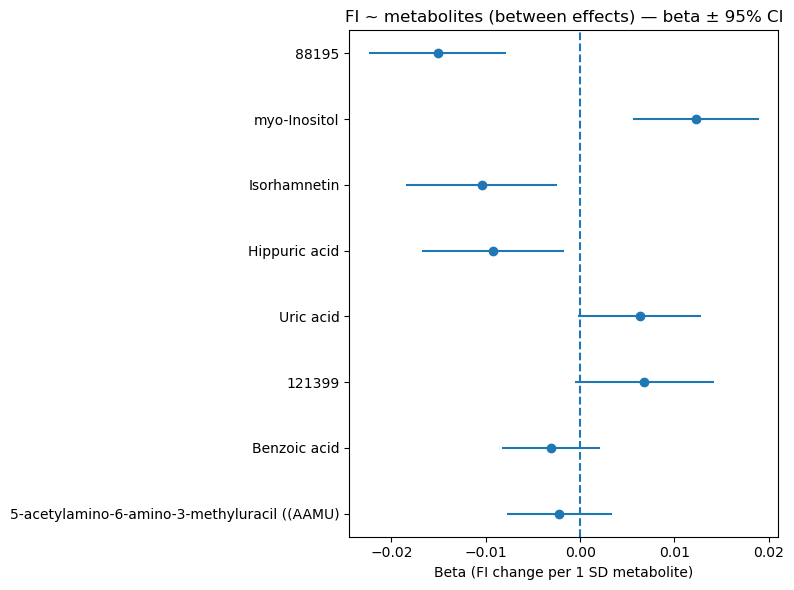

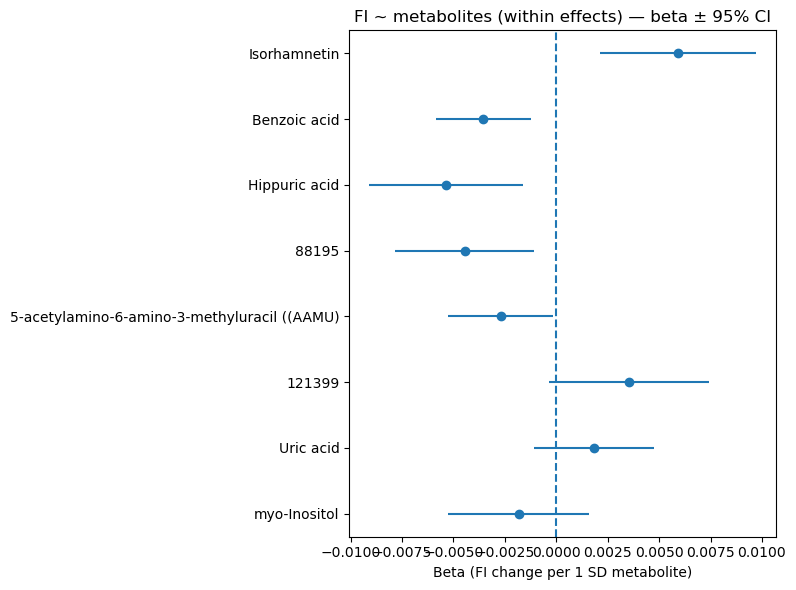

In [311]:
# =========================
# [FI-MET10] FOREST PLOT beta±1.96*SE (BETWEEN e WITHIN separati)
# usa direttamente fit (OLS cluster) e met_to_safe/top_mets creati nella cella [FI-MET8]
# =========================
import matplotlib.pyplot as plt
import numpy as np

def coef_ci(name):
    b = float(fit.params.get(name, np.nan))
    se = float(fit.bse.get(name, np.nan))
    lo = b - 1.96*se
    hi = b + 1.96*se
    return b, lo, hi

# ricostruisci mapping safe->metabolita
safe_to_met = {v: k for k, v in met_to_safe.items()}

def make_forest(effect, topk=10):
    rows = []
    for met in top_mets:
        s = met_to_safe[met]
        name = f"{s}_{effect}"
        b, lo, hi = coef_ci(name)
        p = float(fit.pvalues.get(name, np.nan))
        rows.append({"metabolite": met, "beta": b, "lo": lo, "hi": hi, "p": p})
    out = pd.DataFrame(rows).sort_values("p").head(topk).reset_index(drop=True)
    return out

forest_between = make_forest("between", topk=min(10, len(top_mets)))
forest_within  = make_forest("within",  topk=min(10, len(top_mets)))

def plot_forest(df_forest, title):
    y = np.arange(len(df_forest))
    plt.figure(figsize=(8, 0.5*len(df_forest) + 2))
    plt.errorbar(df_forest["beta"], y,
                 xerr=[df_forest["beta"]-df_forest["lo"], df_forest["hi"]-df_forest["beta"]],
                 fmt="o")
    plt.axvline(0, linestyle="--")
    plt.yticks(y, df_forest["metabolite"].astype(str))
    plt.xlabel("Beta (FI change per 1 SD metabolite)")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_forest(forest_between, "FI ~ metabolites (between effects) — beta ± 95% CI")
plot_forest(forest_within,  "FI ~ metabolites (within effects) — beta ± 95% CI")